<a href="https://colab.research.google.com/github/karthikkumarp2416sse-bit/machine-learning/blob/main/EX_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Learned Means: [14.66847897 21.28479755]
Learned Variances: [np.float64(31.776660141347385), np.float64(1.2474429233281281)]
Learned Weights: [0.79357238 0.20642762]

First 10 cluster assignments: [0 0 0 0 0 0 0 1 0 0]
Number of data points in cluster 0: 187
Number of data points in cluster 1: 63


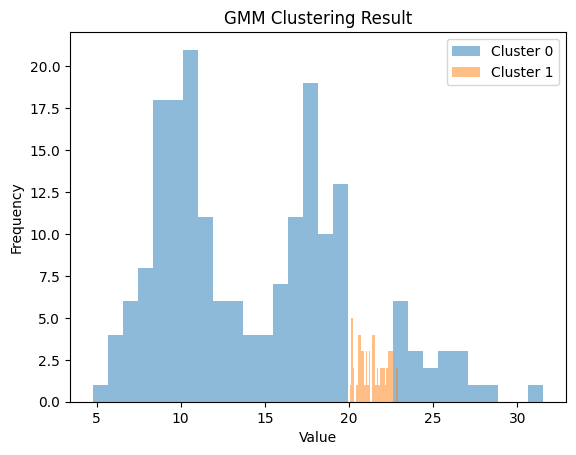

In [ ]:
import numpy as np
from scipy.stats import norm

class GaussianMixtureModel:
    def __init__(self, n_components, max_iter=100, tol=1e-4):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol

    def _initialize_parameters(self, X):
        self.n_samples, self.n_features = X.shape

        random_indices = np.random.choice(self.n_samples, self.n_components, replace=False)
        self.means = X[random_indices]

        self.covariances = [np.eye(self.n_features)] * self.n_components

        self.weights = np.ones(self.n_components) / self.n_components

    def _e_step(self, X):
        responsibilities = np.zeros((self.n_samples, self.n_components))
        for i in range(self.n_components):
            if self.n_features == 1:
                pdf = norm.pdf(X.flatten(), loc=self.means[i][0], scale=np.sqrt(self.covariances[i][0, 0]))
            else:
                raise NotImplementedError("Multivariate Gaussian PDF for GMM not implemented in this basic example.")

            responsibilities[:, i] = self.weights[i] * pdf

        sum_responsibilities = responsibilities.sum(axis=1)[:, np.newaxis]
        responsibilities = responsibilities / (sum_responsibilities + 1e-10)
        return responsibilities

    def _m_step(self, X, responsibilities):
        Nk = responsibilities.sum(axis=0)

        self.means = np.dot(responsibilities.T, X) / (Nk[:, np.newaxis] + 1e-10)

        for i in range(self.n_components):
            diff = X - self.means[i]
            self.covariances[i] = np.dot(responsibilities[:, i] * diff.T, diff) / (Nk[i] + 1e-10)

        self.weights = Nk / (self.n_samples + 1e-10)

    def fit(self, X):
        self._initialize_parameters(X)

        prev_log_likelihood = -np.inf

        for iteration in range(self.max_iter):
            responsibilities = self._e_step(X)

            self._m_step(X, responsibilities)

            current_log_likelihood = self._compute_log_likelihood(X)

            if abs(current_log_likelihood - prev_log_likelihood) < self.tol:
                break
            prev_log_likelihood = current_log_likelihood

    def _compute_log_likelihood(self, X):
        log_likelihood = 0
        for n in range(self.n_samples):
            component_likelihoods = []
            for i in range(self.n_components):
                if self.n_features == 1:
                    pdf = norm.pdf(X[n][0], loc=self.means[i][0], scale=np.sqrt(self.covariances[i][0, 0]))
                else:
                    raise NotImplementedError("Multivariate Gaussian PDF for GMM not implemented in this basic example.")
                component_likelihoods.append(self.weights[i] * pdf)
            log_likelihood += np.log(np.sum(component_likelihoods))
        return log_likelihood

    def predict(self, X):
        responsibilities = np.zeros((X.shape[0], self.n_components))
        for i in range(self.n_components):
            if self.n_features == 1:
                pdf = norm.pdf(X.flatten(), loc=self.means[i][0], scale=np.sqrt(self.covariances[i][0, 0]))
            else:
                raise NotImplementedError("Multivariate Gaussian PDF for GMM not implemented in this basic example.")
            responsibilities[:, i] = self.weights[i] * pdf
        return np.argmax(responsibilities, axis=1)


if __name__ == '__main__':
    np.random.seed(42)
    data1 = np.random.normal(loc=10, scale=2, size=100).reshape(-1, 1)
    data2 = np.random.normal(loc=20, scale=3, size=150).reshape(-1, 1)
    X = np.vstack((data1, data2))
    np.random.shuffle(X)

    gmm = GaussianMixtureModel(n_components=2, max_iter=100, tol=1e-4)
    gmm.fit(X)

    print("Learned Means:", gmm.means.flatten())
    print("Learned Variances:", [cov[0,0] for cov in gmm.covariances])
    print("Learned Weights:", gmm.weights)

    clusters = gmm.predict(X)

    print("\nFirst 10 cluster assignments:", clusters[:10])
    print("Number of data points in cluster 0:", np.sum(clusters == 0))
    print("Number of data points in cluster 1:", np.sum(clusters == 1))

    try:
        import matplotlib.pyplot as plt
        plt.hist(X[clusters == 0], bins=30, alpha=0.5, label='Cluster 0')
        plt.hist(X[clusters == 1], bins=30, alpha=0.5, label='Cluster 1')
        plt.title('GMM Clustering Result')
        plt.xlabel('Value')
        plt.ylabel('Frequency')
        plt.legend()
        plt.show()
    except ImportError:
        print("Matplotlib not found. Skipping visualization.")